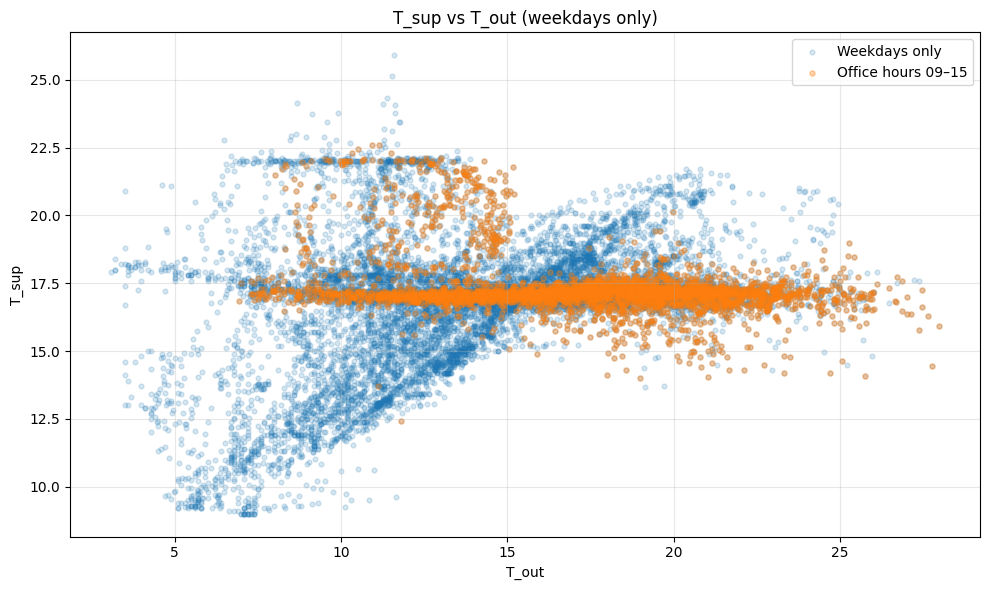

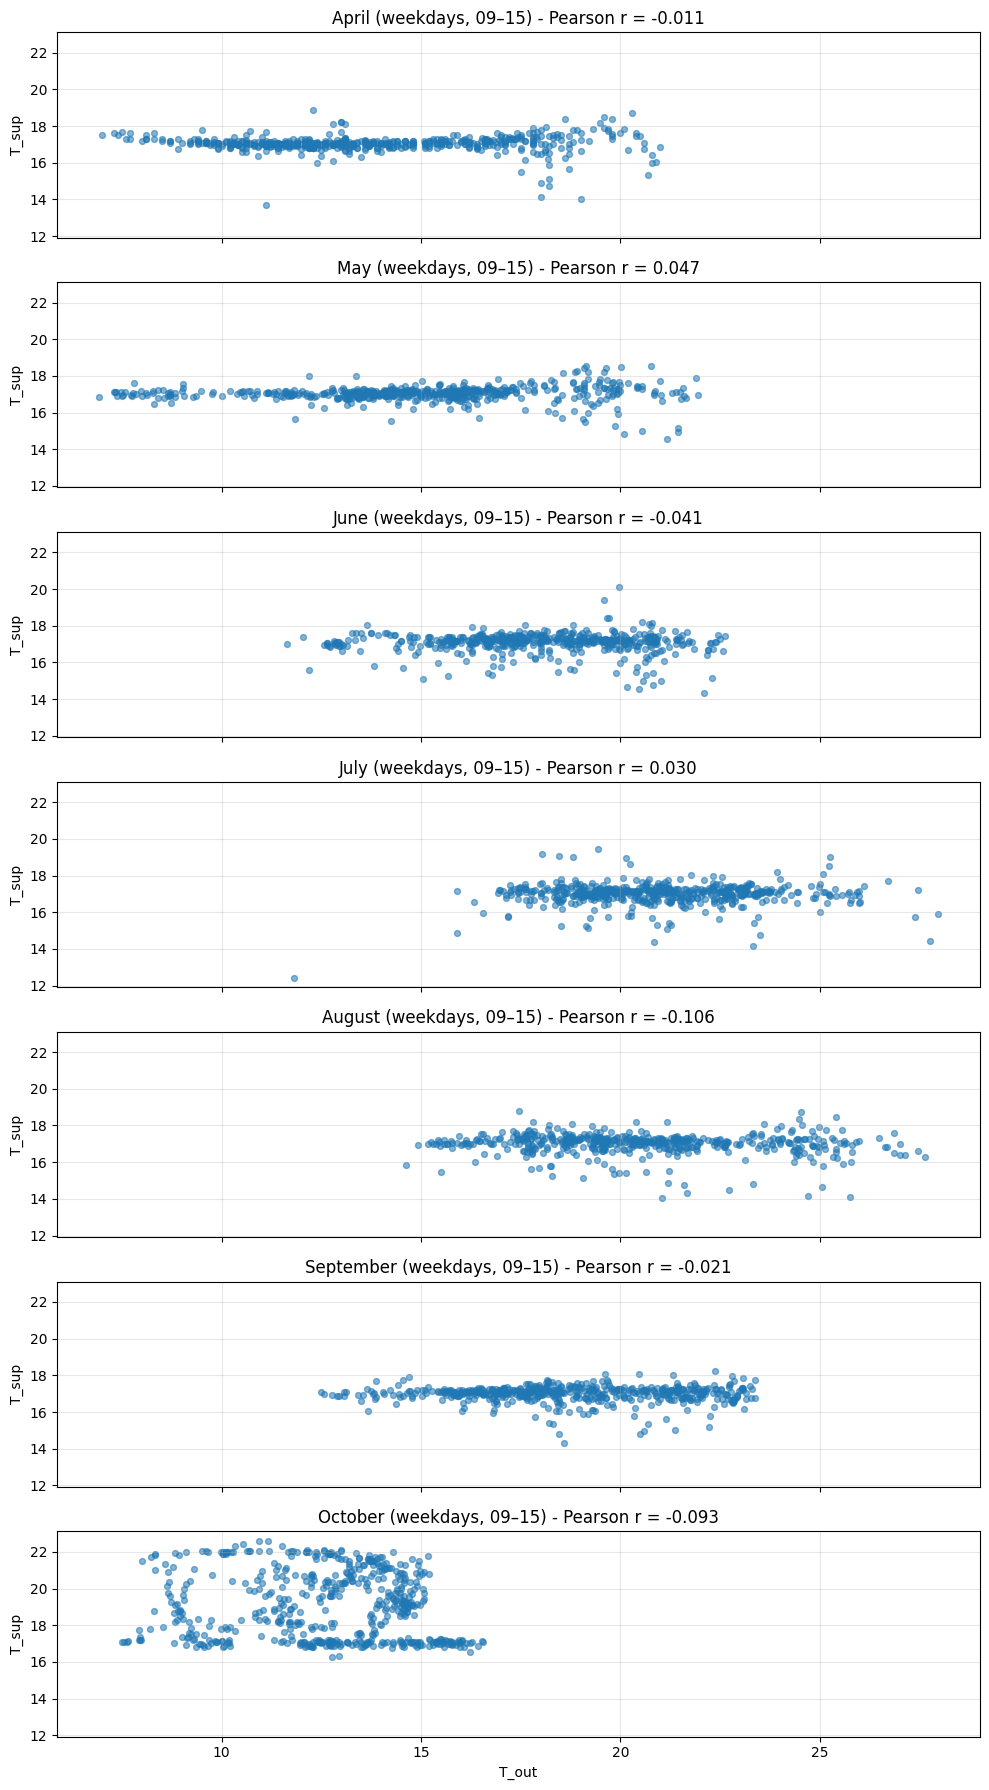

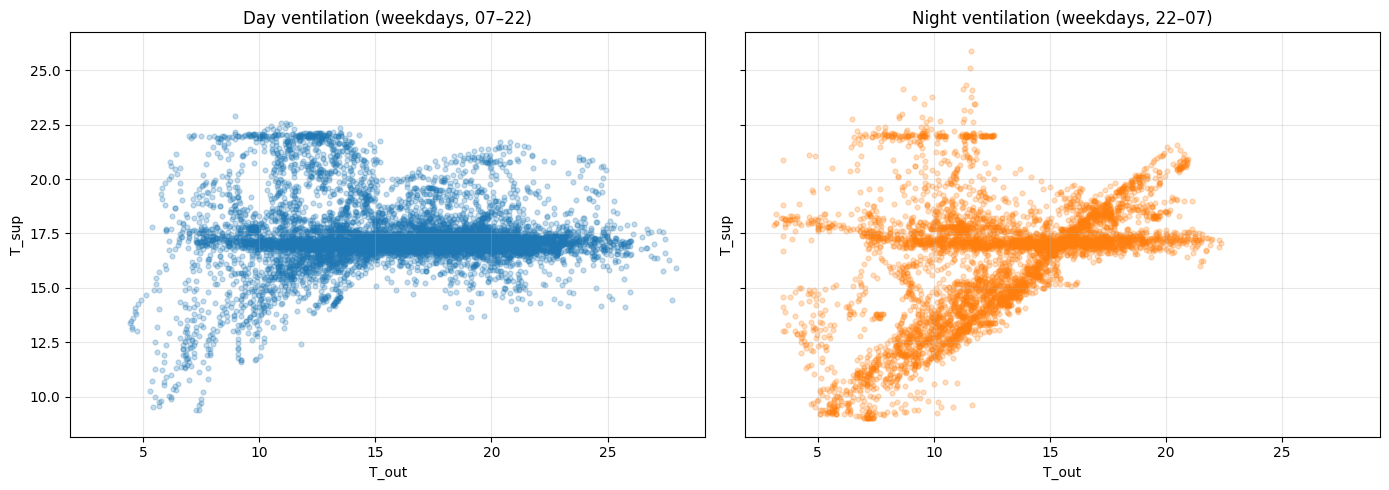

Office-hours monthly correlations (weekdays only):
April: r = -0.011, n = 528
May: r = 0.047, n = 528
June: r = -0.041, n = 504
July: r = 0.030, n = 552
August: r = -0.106, n = 504
September: r = -0.021, n = 528
October: r = -0.093, n = 552

Day correlation (07–22 weekdays): r = 0.030, n = 9240
Night correlation (22–07 weekdays): r = 0.437, n = 5540


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('data/monthly_csv_exports_R05/2025_full_R05.csv')

# Timestamp handling
timestamp_col = df.columns[0]
df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')

# Main columns
x_col = 'HTR9_VES01_TUD01'   # T_out / outdoor temperature
y_col = 'HTRK_VEN01_TI01'    # T_sup / supply temperature

# Keep only rows with valid timestamp and plotted values
df = df.dropna(subset=[timestamp_col, x_col, y_col]).copy()

# Time features
df['month'] = df[timestamp_col].dt.month
df['hour'] = df[timestamp_col].dt.hour
df['weekday'] = df[timestamp_col].dt.weekday   # Monday=0, Sunday=6

# Remove weekends
df = df[df['weekday'] < 5].copy()

# Filters
office_df = df[(df['hour'] >= 9) & (df['hour'] < 15)].copy()
day_df = df[(df['hour'] >= 7) & (df['hour'] < 22)].copy()
night_df = df[(df['hour'] < 7) | (df['hour'] >= 22)].copy()

# Months to show
months = list(range(4, 11))
month_names = ['April', 'May', 'June', 'July', 'August', 'September', 'October']

# -----------------------------
# Plot 1: all weekday data vs office hours
# -----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(df[x_col], df[y_col], alpha=0.18, s=12, label='Weekdays only')
plt.scatter(office_df[x_col], office_df[y_col], alpha=0.35, s=14, label='Office hours 09–15')
plt.xlabel('T_out')
plt.ylabel('T_sup')
plt.title('T_sup vs T_out (weekdays only)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: monthly office-hours plots
# -----------------------------
fig, axes = plt.subplots(len(months), 1, figsize=(10, 18), sharex=True, sharey=True)

for idx, (month, month_name) in enumerate(zip(months, month_names)):
    month_data = office_df[office_df['month'] == month]

    axes[idx].scatter(month_data[x_col], month_data[y_col], alpha=0.55, s=18)
    axes[idx].set_ylabel('T_sup')
    axes[idx].grid(True, alpha=0.3)

    if len(month_data) > 1:
        correlation = month_data[x_col].corr(month_data[y_col])
        axes[idx].set_title(f'{month_name} (weekdays, 09–15) - Pearson r = {correlation:.3f}')
    else:
        axes[idx].set_title(f'{month_name} (weekdays, 09–15) - not enough data')

axes[-1].set_xlabel('T_out')
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: compare day vs night
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

axes[0].scatter(day_df[x_col], day_df[y_col], alpha=0.25, s=12, color='tab:blue')
axes[0].set_title('Day ventilation (weekdays, 07–22)')
axes[0].set_xlabel('T_out')
axes[0].set_ylabel('T_sup')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(night_df[x_col], night_df[y_col], alpha=0.25, s=12, color='tab:orange')
axes[1].set_title('Night ventilation (weekdays, 22–07)')
axes[1].set_xlabel('T_out')
axes[1].set_ylabel('T_sup')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# Optional: print correlations
# -----------------------------
print('Office-hours monthly correlations (weekdays only):')
for month, month_name in zip(months, month_names):
    month_data = office_df[office_df['month'] == month]
    if len(month_data) > 1:
        correlation = month_data[x_col].corr(month_data[y_col])
        print(f'{month_name}: r = {correlation:.3f}, n = {len(month_data)}')
    else:
        print(f'{month_name}: not enough data')

if len(day_df) > 1:
    print(f'\nDay correlation (07–22 weekdays): r = {day_df[x_col].corr(day_df[y_col]):.3f}, n = {len(day_df)}')

if len(night_df) > 1:
    print(f'Night correlation (22–07 weekdays): r = {night_df[x_col].corr(night_df[y_col]):.3f}, n = {len(night_df)}')

In [4]:
import numpy as np

night_data = night_df.dropna(subset=[x_col, y_col]).copy()

x = night_data[x_col]
y = night_data[y_col]

coef = np.polyfit(x, y, 1)
a, b = coef[0], coef[1]

print(f"T_sup = {a:.4f} * T_out + {b:.4f}")

T_sup = 0.3045 * T_out + 12.3914


Night fit results:
    Month   n        a         b       r2
    April 792 0.254145 12.117756 0.043187
      May 792 0.488145  9.820745 0.172754
     June 756 0.327435 11.864724 0.125865
     July 828 0.276016 12.949531 0.205341
   August 756 0.379217 11.077040 0.443549
September 792 0.388867 10.853672 0.441472
  October 824 0.065613 16.710719 0.001180

Office-hour fit results:
    Month   n         a         b       r2
    April 528 -0.001681 17.073853 0.000131
      May 528  0.006337 16.948723 0.002230
     June 504 -0.009807 17.256449 0.001666
     July 552  0.007789 16.840293 0.000897
   August 504 -0.022233 17.456541 0.011223
September 528 -0.003724 17.062399 0.000458


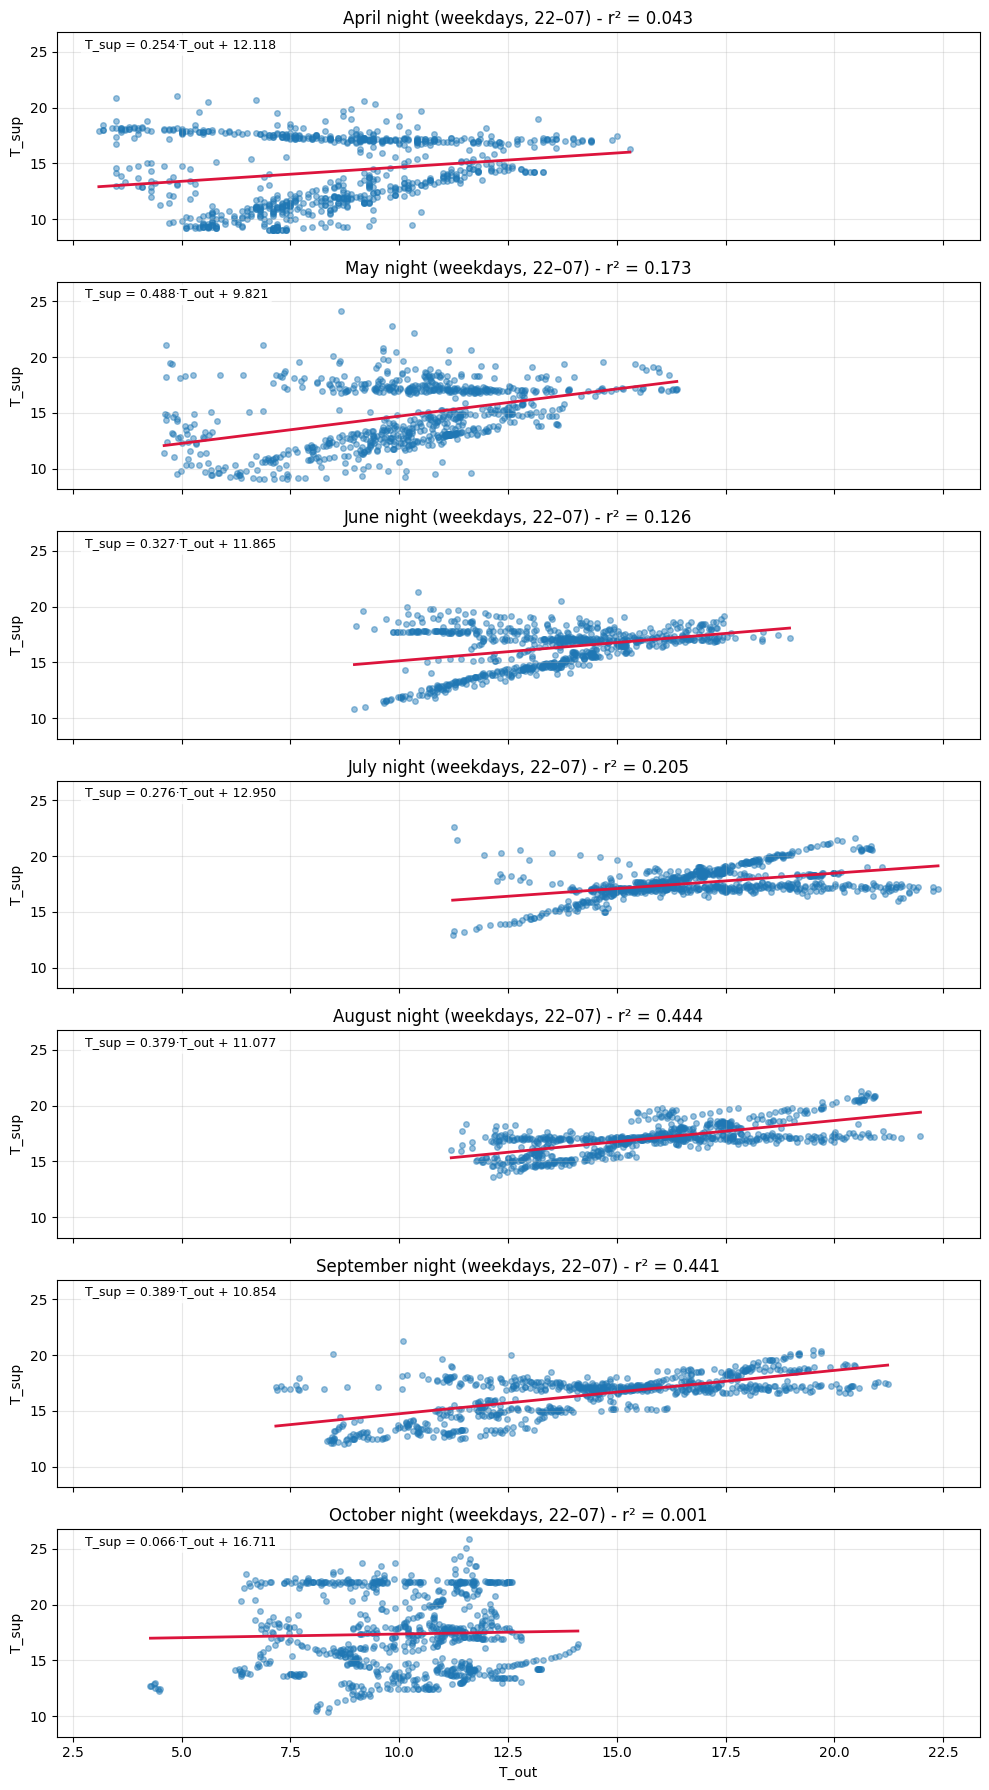

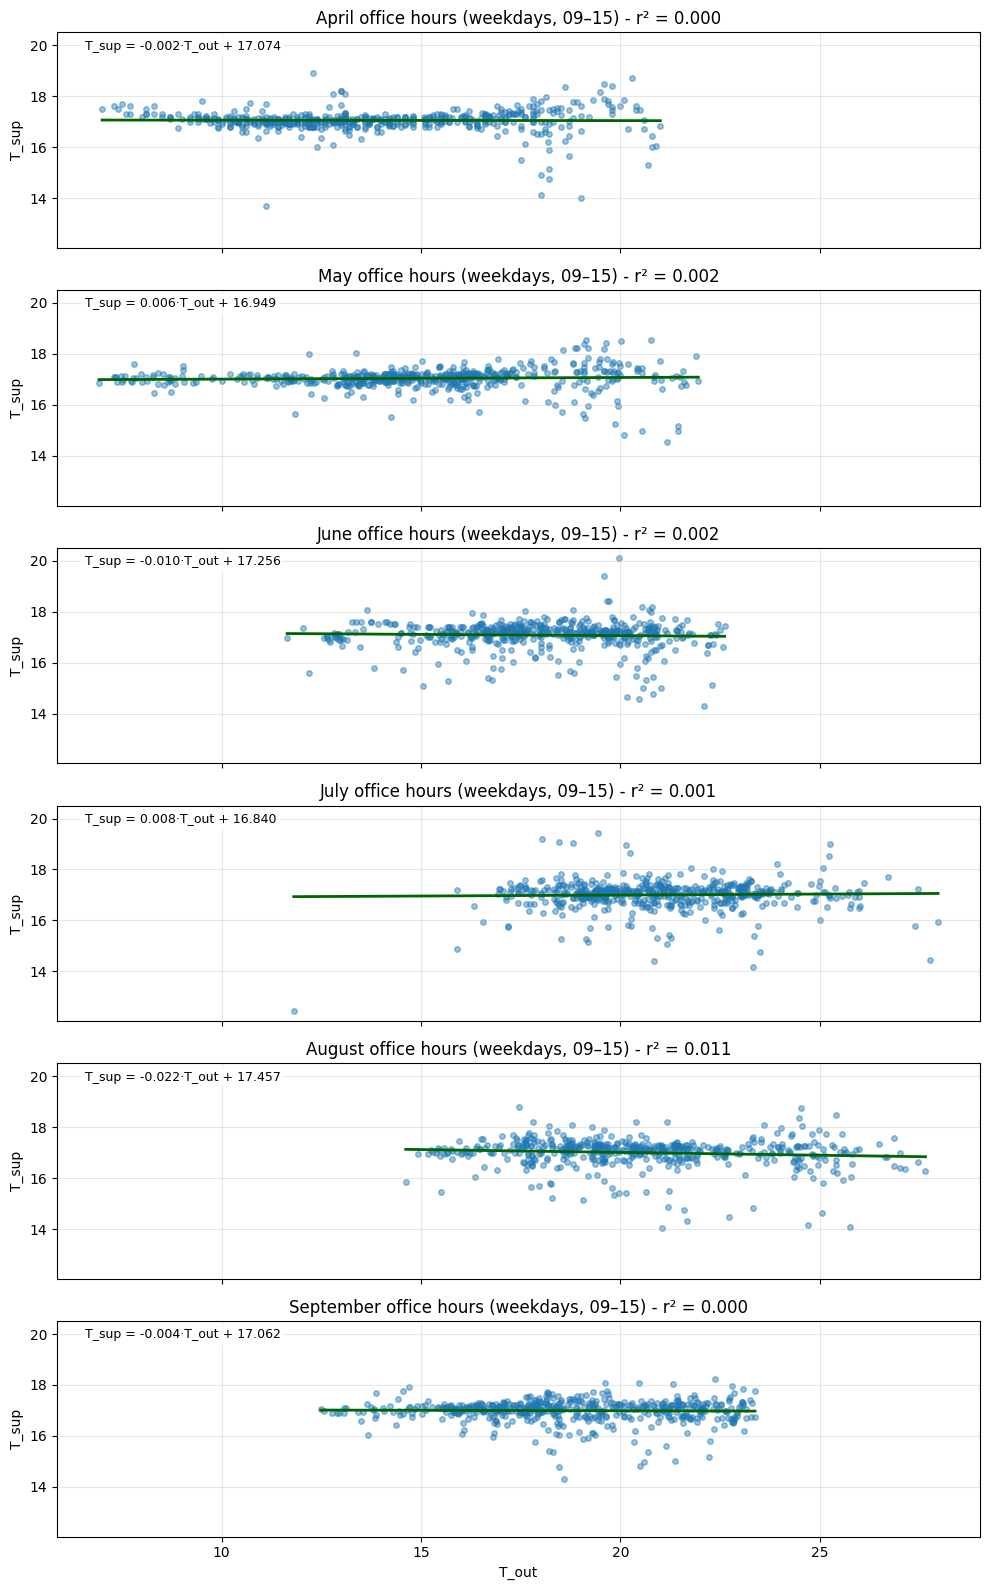

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('data/monthly_csv_exports_R05/2025_full_R05.csv')

# Timestamp handling
timestamp_col = df.columns[0]
df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')

# Main columns
x_col = 'HTR9_VES01_TUD01'   # T_out / outdoor temperature
y_col = 'HTRK_VEN01_TI01'    # T_sup / supply temperature

# Keep only valid rows
df = df.dropna(subset=[timestamp_col, x_col, y_col]).copy()

# Time features
df['month'] = df[timestamp_col].dt.month
df['hour'] = df[timestamp_col].dt.hour
df['weekday'] = df[timestamp_col].dt.weekday  # Monday=0, Sunday=6

# Remove weekends
df = df[df['weekday'] < 5].copy()

# Filters
office_df = df[(df['hour'] >= 9) & (df['hour'] < 15)].copy()
night_df = df[(df['hour'] < 7) | (df['hour'] >= 22)].copy()

# Months to show
months = [4, 5, 6, 7, 8, 9, 10]
month_names = ['April', 'May', 'June', 'July', 'August', 'September', 'October']

# Months for last plot only (October removed)
months_office = [4, 5, 6, 7, 8, 9]
month_names_office = ['April', 'May', 'June', 'July', 'August', 'September']

# -----------------------------
# Helper: fit linear model
# -----------------------------
def fit_linear(data, x_col, y_col):
    x = data[x_col].to_numpy()
    y = data[y_col].to_numpy()

    if len(data) < 2:
        return np.nan, np.nan, np.nan

    a, b = np.polyfit(x, y, 1)
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return a, b, r2

# -----------------------------
# Night fits by month
# -----------------------------
night_results = []
for month, month_name in zip(months, month_names):
    mdf = night_df[night_df['month'] == month].copy()
    a, b, r2 = fit_linear(mdf, x_col, y_col)
    night_results.append([month_name, len(mdf), a, b, r2])

night_results_df = pd.DataFrame(
    night_results,
    columns=['Month', 'n', 'a', 'b', 'r2']
)

print('Night fit results:')
print(night_results_df.to_string(index=False))

# -----------------------------
# Office-hour fits by month
# -----------------------------
office_results = []
for month, month_name in zip(months_office, month_names_office):
    mdf = office_df[office_df['month'] == month].copy()
    a, b, r2 = fit_linear(mdf, x_col, y_col)
    office_results.append([month_name, len(mdf), a, b, r2])

office_results_df = pd.DataFrame(
    office_results,
    columns=['Month', 'n', 'a', 'b', 'r2']
)

print('\nOffice-hour fit results:')
print(office_results_df.to_string(index=False))

# -----------------------------
# Plot monthly night fits
# -----------------------------
fig, axes = plt.subplots(len(months), 1, figsize=(10, 18), sharex=True, sharey=True)

for idx, (month, month_name) in enumerate(zip(months, month_names)):
    mdf = night_df[night_df['month'] == month].copy()
    ax = axes[idx]
    ax.scatter(mdf[x_col], mdf[y_col], alpha=0.45, s=16)

    if len(mdf) >= 2:
        a, b, r2 = fit_linear(mdf, x_col, y_col)
        x_line = np.linspace(mdf[x_col].min(), mdf[x_col].max(), 100)
        y_line = a * x_line + b
        ax.plot(x_line, y_line, color='crimson', lw=2)

        ax.set_title(f'{month_name} night (weekdays, 22–07) - r² = {r2:.3f}')
        ax.text(
            0.03, 0.92,
            f'T_sup = {a:.3f}·T_out + {b:.3f}',
            transform=ax.transAxes,
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
        )
    else:
        ax.set_title(f'{month_name} night (weekdays, 22–07) - not enough data')

    ax.set_ylabel('T_sup')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('T_out')
plt.tight_layout()
plt.show()

# -----------------------------
# Plot monthly office-hour fits
# -----------------------------
fig, axes = plt.subplots(len(months_office), 1, figsize=(10, 16), sharex=True, sharey=True)

for idx, (month, month_name) in enumerate(zip(months_office, month_names_office)):
    mdf = office_df[office_df['month'] == month].copy()
    ax = axes[idx]
    ax.scatter(mdf[x_col], mdf[y_col], alpha=0.45, s=16)

    if len(mdf) >= 2:
        a, b, r2 = fit_linear(mdf, x_col, y_col)
        x_line = np.linspace(mdf[x_col].min(), mdf[x_col].max(), 100)
        y_line = a * x_line + b
        ax.plot(x_line, y_line, color='darkgreen', lw=2)

        ax.set_title(f'{month_name} office hours (weekdays, 09–15) - r² = {r2:.3f}')
        ax.text(
            0.03, 0.92,
            f'T_sup = {a:.3f}·T_out + {b:.3f}',
            transform=ax.transAxes,
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
        )
    else:
        ax.set_title(f'{month_name} office hours (weekdays, 09–15) - not enough data')

    ax.set_ylabel('T_sup')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('T_out')
plt.tight_layout()
plt.show()